# Gallstone Disease — Predictive Models Analysis
**Course:** Modelos Predictivos — Parcial I  
**Dataset:** Gallstone UCI (`dataset-uci.csv`)  
**Task:** Binary Classification — predict `Gallstone Status` (0 / 1)  
**Author:** Sergio Florez  
---

## Notebook Index
1. Dataset Description  
   1.1 Context and Objective  
   1.2 Feature Descriptions  
2. Data Loading & Global Cleaning  
   2.1 Load Data  
   2.2 Quality Check  
   2.3 Cleaning Steps  
3. Train/Test Split  
   3.1 Split Configuration  
   3.2 Split Verification  
4. Exploratory Data Analysis (Training Set Only)  
   4.1 Do lab values differ between classes?  
   4.2 Is there dangerous multicollinearity among body composition features?  
   4.3 What is the demographic profile by disease status?  
5. Feature Engineering & Selection  
   5.1 Drop Redundant Features  
   5.2 Correlation-Based Filtering  
   5.3 SelectKBest Ranking  
   5.4 Final Feature Set  
6. Model Training & Cross-Validation  
   6.1 Baseline — DummyClassifier  
   6.2 Model 1 — Logistic Regression  
   6.3 Model 2 — Random Forest  
   6.4 CV Comparison Table  
7. Final Evaluation on Test Set  
   7.1 Metrics Table  
   7.2 Diagnostic Plots  
   7.3 CV vs. Test Comparison  
8. Conclusions

In [1]:
# Only installs what Colab doesn't have by default
!pip install -q imbalanced-learn xgboost

In [2]:
# ── Standard library ────────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings("ignore")

# ── Data manipulation ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Sklearn — data splitting & CV ────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
)

# ── Sklearn — preprocessing & pipelines ─────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# ── Sklearn — models ─────────────────────────────────────────────────────────
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ── Sklearn — metrics ────────────────────────────────────────────────────────
from sklearn.metrics import (
    recall_score, f1_score, precision_score,
    accuracy_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay,
    classification_report,
)


## Project Constants
All configurable values are defined here. Never hardcode these values inline — change them once here and every cell updates automatically.

In [3]:
# ── Reproducibility & split configuration ────────────────────────────────────
RANDOM_STATE  = 123
TEST_SIZE     = 0.2

# ── Dataset path (uploaded to Colab session) ─────────────────────────────────
DATA_PATH     = "/content/dataset-uci.csv"

# ── Target column ─────────────────────────────────────────────────────────────
TARGET_COL    = "Gallstone Status"

# ── Feature selection ─────────────────────────────────────────────────────────
K_BEST        = 15          # Top-k features to keep via SelectKBest
CORR_THRESH   = 0.90        # Drop one feature from any pair above this threshold

# ── CV configuration ──────────────────────────────────────────────────────────
N_FOLDS       = 5

# ── Plot output folder (saves figures in Drive if mounted, or /content/) ──────
FIG_DIR       = "/content/figures_gallstone"
os.makedirs(FIG_DIR, exist_ok=True)

print("Constants defined ✅")
print(f"  RANDOM_STATE : {RANDOM_STATE}")
print(f"  TEST_SIZE    : {TEST_SIZE}")
print(f"  K_BEST       : {K_BEST}")
print(f"  CORR_THRESH  : {CORR_THRESH}")
print(f"  N_FOLDS      : {N_FOLDS}")
print(f"  FIG_DIR      : {FIG_DIR}")

Constants defined ✅
  RANDOM_STATE : 123
  TEST_SIZE    : 0.2
  K_BEST       : 15
  CORR_THRESH  : 0.9
  N_FOLDS      : 5
  FIG_DIR      : /content/figures_gallstone


## Environment Verification
Confirm the dataset is readable and matches the expected shape before touching any data.  
**Expected shape:** (319, 38) — 319 patients, 38 features (plus the target column, so 39 total raw columns).

In [4]:
# ── Verify the CSV is accessible and matches expected dimensions ─────────────
try:
    _df_check = pd.read_csv(DATA_PATH)
    print(f"File loaded successfully ✅")
    print(f"  Shape       : {_df_check.shape}")
    print(f"  Columns     : {_df_check.shape[1]}")
    print(f"  Rows        : {_df_check.shape[0]}")

    # Soft assertion — warns without crashing if shape is unexpected
    expected_rows, expected_cols = 319, 39  # 38 features + 1 target
    if _df_check.shape != (expected_rows, expected_cols):
        print(f"\n⚠️  Unexpected shape. Got {_df_check.shape}, expected ({expected_rows}, {expected_cols}).")
        print("   Check that you uploaded the correct file.")
    else:
        print(f"\nShape matches expected {(expected_rows, expected_cols)} ✅")

    assert TARGET_COL in _df_check.columns, f"Target column '{TARGET_COL}' not found!"
    print(f"Target column '{TARGET_COL}' present ✅")

except FileNotFoundError:
    print(f"❌ File not found at: {DATA_PATH}")
    print("   → Go to Colab sidebar > Files > Upload, then re-run this cell.")

File loaded successfully ✅
  Shape       : (319, 39)
  Columns     : 39
  Rows        : 319

Shape matches expected (319, 39) ✅
Target column 'Gallstone Status' present ✅


## 2. Data Loading & Global Cleaning

### 2.1 Load Data


In [5]:
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"\nColumn names:")
for i, col in enumerate(df.columns):
    print(f"  {i:2d}: '{col}'")

Shape: (319, 39)

Column names:
   0: 'Gallstone Status'
   1: 'Age'
   2: 'Gender'
   3: 'Comorbidity'
   4: 'Coronary Artery Disease (CAD)'
   5: 'Hypothyroidism'
   6: 'Hyperlipidemia'
   7: 'Diabetes Mellitus (DM)'
   8: 'Height'
   9: 'Weight'
  10: 'Body Mass Index (BMI)'
  11: 'Total Body Water (TBW)'
  12: 'Extracellular Water (ECW)'
  13: 'Intracellular Water (ICW)'
  14: 'Extracellular Fluid/Total Body Water (ECF/TBW)'
  15: 'Total Body Fat Ratio (TBFR) (%)'
  16: 'Lean Mass (LM) (%)'
  17: 'Body Protein Content (Protein) (%)'
  18: 'Visceral Fat Rating (VFR)'
  19: 'Bone Mass (BM)'
  20: 'Muscle Mass (MM)'
  21: 'Obesity (%)'
  22: 'Total Fat Content (TFC)'
  23: 'Visceral Fat Area (VFA)'
  24: 'Visceral Muscle Area (VMA) (Kg)'
  25: 'Hepatic Fat Accumulation (HFA)'
  26: 'Glucose'
  27: 'Total Cholesterol (TC)'
  28: 'Low Density Lipoprotein (LDL)'
  29: 'High Density Lipoprotein (HDL)'
  30: 'Triglyceride'
  31: 'Aspartat Aminotransferaz (AST)'
  32: 'Alanin Aminotransfera

### 2.2 Quality Check

Inspect data types, missing values, and a statistical summary.  
No transformations yet — only observation and documentation.

In [6]:
# ── Data types ───────────────────────────────────────────────────────────────
print("=== Data Types ===")
print(df.dtypes)
print()

# ── Missing values ───────────────────────────────────────────────────────────
missing = df.isnull().sum()
print("=== Missing Values ===")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values ✅")
print()

# ── Value ranges (numeric summary) ───────────────────────────────────────────
print("=== Statistical Summary ===")
print(df.describe().round(2).to_string())

=== Data Types ===
Gallstone Status                                    int64
Age                                                 int64
Gender                                              int64
Comorbidity                                         int64
Coronary Artery Disease (CAD)                       int64
Hypothyroidism                                      int64
Hyperlipidemia                                      int64
Diabetes Mellitus (DM)                              int64
Height                                              int64
Weight                                            float64
Body Mass Index (BMI)                             float64
Total Body Water (TBW)                            float64
Extracellular Water (ECW)                         float64
Intracellular Water (ICW)                         float64
Extracellular Fluid/Total Body Water (ECF/TBW)    float64
Total Body Fat Ratio (TBFR) (%)                   float64
Lean Mass (LM) (%)                                flo

### 2.3 Cleaning Steps

#### 2.3.1 — Column name registry

All full column names are registered here as a single source of truth.  
Future phases reference `COLS['key']` instead of hardcoding long strings.

In [7]:
# ── Single source of truth for column names ───────────────────────────────────
COLS = {
    # Target
    "target"         : "Gallstone Status",
    # Demographics
    "age"            : "Age",
    "gender"         : "Gender",
    # Comorbidity
    "comorbidity"    : "Comorbidity",
    "cad"            : "Coronary Artery Disease (CAD)",
    "hypothyroidism" : "Hypothyroidism",
    "hyperlipidemia" : "Hyperlipidemia",
    "dm"             : "Diabetes Mellitus (DM)",
    # Anthropometrics
    "height"         : "Height",
    "weight"         : "Weight",
    "bmi"            : "Body Mass Index (BMI)",
    "obesity"        : "Obesity (%)",
    # Body composition
    "tbw"            : "Total Body Water (TBW)",
    "ecw"            : "Extracellular Water (ECW)",
    "icw"            : "Intracellular Water (ICW)",
    "ecf_tbw"        : "Extracellular Fluid/Total Body Water (ECF/TBW)",
    "tbfr"           : "Total Body Fat Ratio (TBFR) (%)",
    "lean_mass"      : "Lean Mass (LM) (%)",
    "protein"        : "Body Protein Content (Protein) (%)",
    "vfr"            : "Visceral Fat Rating (VFR)",
    "bone_mass"      : "Bone Mass (BM)",
    "muscle_mass"    : "Muscle Mass (MM)",
    "tfc"            : "Total Fat Content (TFC)",
    "vfa"            : "Visceral Fat Area (VFA)",
    "vma"            : "Visceral Muscle Area (VMA) (Kg)",
    "hfa"            : "Hepatic Fat Accumulation (HFA)",
    # Lab values
    "glucose"        : "Glucose",
    "cholesterol"    : "Total Cholesterol (TC)",
    "ldl"            : "Low Density Lipoprotein (LDL)",
    "hdl"            : "High Density Lipoprotein (HDL)",
    "triglyceride"   : "Triglyceride",
    "ast"            : "Aspartat Aminotransferaz (AST)",
    "alt"            : "Alanin Aminotransferaz (ALT)",
    "alp"            : "Alkaline Phosphatase (ALP)",
    "creatinine"     : "Creatinine",
    "gfr"            : "Glomerular Filtration Rate (GFR)",
    "crp"            : "C-Reactive Protein (CRP)",
    "hgb"            : "Hemoglobin (HGB)",
    "vitamin_d"      : "Vitamin D",
}

print(f"Column registry defined ✅  ({len(COLS)} entries)")

Column registry defined ✅  (39 entries)


#### 2.3.2 — Verify binary columns

Confirm that `Gender`, `CAD`, `Hypothyroidism`, `Hyperlipidemia`, and `DM` contain only 0/1 values.  
All columns are already numeric — we verify the value range only.

In [8]:
binary_cols = [
    COLS["gender"],
    COLS["cad"],
    COLS["hypothyroidism"],
    COLS["hyperlipidemia"],
    COLS["dm"],
]

print("=== Binary Column Check ===")
all_ok = True
for col in binary_cols:
    actual  = set(df[col].dropna().unique())
    allowed = {0, 1}
    status  = "✅" if actual <= allowed else "⚠️ "
    if actual > allowed:
        all_ok = False
    print(f"  {status} {col}: {sorted(actual)}")

print()
if all_ok:
    print("All binary columns confirmed as 0/1 ✅ — no encoding needed.")
else:
    print("⚠️  Some columns have unexpected values — inspect above.")

=== Binary Column Check ===
  ✅ Gender: [np.int64(0), np.int64(1)]
  ✅ Coronary Artery Disease (CAD): [np.int64(0), np.int64(1)]
  ✅ Hypothyroidism: [np.int64(0), np.int64(1)]
  ✅ Hyperlipidemia: [np.int64(0), np.int64(1)]
  ✅ Diabetes Mellitus (DM): [np.int64(0), np.int64(1)]

All binary columns confirmed as 0/1 ✅ — no encoding needed.


#### 2.3.3 — Check `Comorbidity` redundancy

**Hypothesis:** `Comorbidity` is a derived column from `CAD`, `Hypothyroidism`, `Hyperlipidemia`, and `DM`.  
The statistical summary showed `max = 3`, suggesting it may be a **count** of active comorbidities rather than a simple OR flag.  
We test both hypotheses. If either is confirmed, `Comorbidity` is redundant and will be dropped in Phase 4.

In [9]:
components = [
    COLS["cad"],
    COLS["hypothyroidism"],
    COLS["hyperlipidemia"],
    COLS["dm"],
]

comorbidity_col = COLS["comorbidity"]

# ── Hypothesis A: Comorbidity = OR (binary flag) ──────────────────────────────
derived_or    = (df[components].sum(axis=1) > 0).astype(int)
match_or      = (derived_or == df[comorbidity_col]).sum()

# ── Hypothesis B: Comorbidity = SUM (count) ───────────────────────────────────
derived_sum   = df[components].sum(axis=1).astype(int)
match_sum     = (derived_sum == df[comorbidity_col]).sum()

total = len(df)

print(f"=== Comorbidity Redundancy Check ===")
print(f"  Unique values in Comorbidity : {sorted(df[comorbidity_col].unique())}")
print()
print(f"  Hypothesis A — binary OR flag:")
print(f"    Matching rows : {match_or} / {total}  ({match_or/total:.1%})")
print()
print(f"  Hypothesis B — sum / count of components:")
print(f"    Matching rows : {match_sum} / {total}  ({match_sum/total:.1%})")
print()

if match_sum == total:
    print("✅ CONFIRMED: Comorbidity = SUM of components (count).")
    print("   → Redundant. Will be DROPPED in Phase 4.")
    COMORBIDITY_IS_DERIVED = True
elif match_or == total:
    print("✅ CONFIRMED: Comorbidity = OR of components (binary flag).")
    print("   → Redundant. Will be DROPPED in Phase 4.")
    COMORBIDITY_IS_DERIVED = True
elif max(match_or, match_sum) / total >= 0.95:
    print("⚠️  Near-perfect match — likely derived with minor data entry errors.")
    print("   → Will be DROPPED in Phase 4.")
    COMORBIDITY_IS_DERIVED = True
else:
    print("❌ Comorbidity does NOT appear to be derived from its components.")
    print("   → Retains independent information. Keep for now.")
    COMORBIDITY_IS_DERIVED = False

print(f"\nCOMORBIDITY_IS_DERIVED = {COMORBIDITY_IS_DERIVED}")

=== Comorbidity Redundancy Check ===
  Unique values in Comorbidity : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

  Hypothesis A — binary OR flag:
    Matching rows : 282 / 319  (88.4%)

  Hypothesis B — sum / count of components:
    Matching rows : 278 / 319  (87.1%)

❌ Comorbidity does NOT appear to be derived from its components.
   → Retains independent information. Keep for now.

COMORBIDITY_IS_DERIVED = False


#### 2.3.4 — Verify target column

Confirm `Gallstone Status` contains only 0 and 1, and record the class distribution.  
Class balance here determines whether `stratify=y` is critical in the split.

In [10]:
print("=== Target Column Verification ===")
print(f"  Column        : '{COLS['target']}'")
print(f"  Unique values : {sorted(df[COLS['target']].unique())}")
print()

counts = df[COLS["target"]].value_counts().sort_index()
props  = df[COLS["target"]].value_counts(normalize=True).sort_index()

for cls in counts.index:
    print(f"  Class {cls} : {counts[cls]} rows  ({props[cls]:.1%})")

print()

# Validity check
if set(df[COLS["target"]].unique()) <= {0, 1}:
    print("✅ Target is valid binary (0 / 1).")
else:
    print("⚠️  Unexpected values in target — inspect manually.")

# Balance check
majority = props.max()
if majority > 0.65:
    print(f"⚠️  Class imbalance detected — majority class is {majority:.1%}.")
    print("   → stratify=y in the split is critical.")
else:
    print(f"✅ Classes are approximately balanced ({majority:.1%} majority).")
    print("   → stratify=y still used as best practice for small datasets.")

=== Target Column Verification ===
  Column        : 'Gallstone Status'
  Unique values : [np.int64(0), np.int64(1)]

  Class 0 : 161 rows  (50.5%)
  Class 1 : 158 rows  (49.5%)

✅ Target is valid binary (0 / 1).
✅ Classes are approximately balanced (50.5% majority).
   → stratify=y still used as best practice for small datasets.


---
## 3. Train/Test Split

The split is the most critical operation in the pipeline. It is performed here, before any EDA or statistical transformation, to guarantee that no information from the test set influences feature engineering decisions or model training.

### 3.1 Split Configuration


In [12]:
# ── 3.1 Train/Test Split ──────────────────────────────────────────────────────
X = df.drop(columns=[COLS["target"]])
y = df[COLS["target"]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Split completed.")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : {y_train.shape}")
print(f"  y_test  : {y_test.shape}")

Split completed.
  X_train : (255, 38)
  X_test  : (64, 38)
  y_train : (255,)
  y_test  : (64,)


### 3.2 Split Verification

**Interpretation note:** The 80/20 split is mathematically correct for 319 rows (rounding artifact: 63.8 → 64). Stratification is working perfectly — both splits maintain the 50/50 class balance.

**Known limitation:** 64 test rows is a small absolute count. A single misclassification shifts F1 by approximately ±1.5%, meaning individual test metrics carry high variance. Per this project's design, **5-fold cross-validation results are the primary performance estimate**. Test set results are treated as directional confirmation only.

Verifying that the class distribution is preserved in both splits (effect of the `stratify=y` parameter), and that the sizes are consistent with `TEST_SIZE = 0.2`.

In [13]:
# ── 3.2 Verificación del split ────────────────────────────────────────────────
train_dist = y_train.value_counts(normalize=True).sort_index()
test_dist  = y_test.value_counts(normalize=True).sort_index()

print("Class distribution — y_train:")
for cls, pct in train_dist.items():
    print(f"  Class {cls}: {y_train.value_counts()[cls]:>3} rows  ({pct:.1%})")

print("\nClass distribution — y_test:")
for cls, pct in test_dist.items():
    print(f"  Class {cls}: {y_test.value_counts()[cls]:>3} rows  ({pct:.1%})")

print("\nSplit summary:")
print(f"  Total original rows : {len(df)}")
print(f"  Train               : {len(X_train)} rows ({len(X_train)/len(df):.1%})")
print(f"  Test                : {len(X_test)} rows  ({len(X_test)/len(df):.1%})")
print(f"  Stratification      : {'✅ OK' if abs(train_dist[0] - test_dist[0]) < 0.02 else '⚠️ CHECK'}")


Class distribution — y_train:
  Class 0: 129 rows  (50.6%)
  Class 1: 126 rows  (49.4%)

Class distribution — y_test:
  Class 0:  32 rows  (50.0%)
  Class 1:  32 rows  (50.0%)

Split summary:
  Total original rows : 319
  Train               : 255 rows (79.9%)
  Test                : 64 rows  (20.1%)
  Stratification      : ✅ OK


---
## 4. Exploratory Data Analysis (Training Set)

> **Ground rule:** All statistics and visualizations in this section are computed exclusively
> on `X_train` and `y_train`. The test set is not referenced until Phase 6.
> Every finding explicitly connects to a specific action in Phase 4 (Feature Engineering & Selection).

**Three questions addressed:**
- **4.1** Do laboratory values differ meaningfully between gallstone-positive and negative patients?
- **4.2** Is there dangerous multicollinearity among body composition features?
- **4.3** What is the demographic profile of patients, and does it differ by disease status?

### 4.1 Do laboratory values differ meaningfully between gallstone-positive and negative patients?

**Hypothesis:** Gallstone-positive patients (class 1) will show higher glucose, cholesterol, LDL,
and triglyceride levels, and elevated CRP (inflammation marker), compared to negative patients.
These are the most clinically actionable signals in the dataset.

**Visualization:** Side-by-side boxplots of 5 key lab values grouped by `Gallstone Status`.

**Phase 4 action:** Features with no visible separation between classes will be flagged
as candidates for removal during univariate feature selection (SelectKBest).

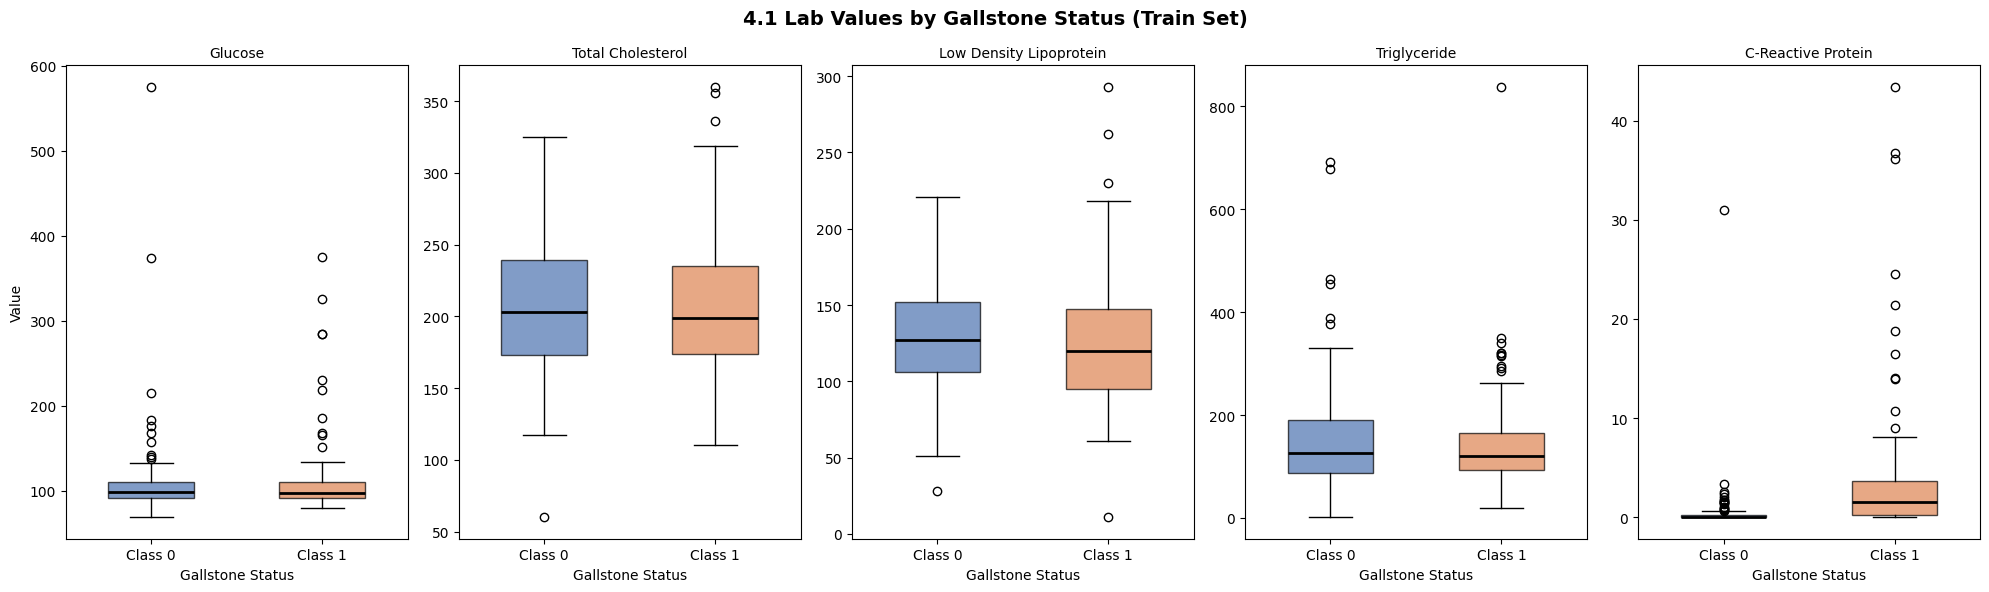

Figure saved: 4_1_lab_values_by_class.png

Median values by class (train set):
                  Glucose  Total Cholesterol (TC)  Low Density Lipoprotein (LDL)  Triglyceride  C-Reactive Protein (CRP)
Gallstone Status                                                                                                        
0                    99.0                   203.0                          127.0         127.0                      0.00
1                    98.0                   199.0                          120.0         119.5                      1.55


In [15]:
# --- 4.1 Lab values by Gallstone Status ---
lab_cols = [
    COLS["glucose"], COLS["cholesterol"], COLS["ldl"],
    COLS["triglyceride"], COLS["crp"]
]

train_eda = X_train.copy()
train_eda[COLS["target"]] = y_train.values

fig, axes = plt.subplots(1, 5, figsize=(20, 6))
fig.suptitle("4.1 Lab Values by Gallstone Status (Train Set)", fontsize=14, fontweight="bold")

for ax, col in zip(axes, lab_cols):
    for cls, color, label in zip([0, 1], ["#4C72B0", "#DD8452"], ["No Gallstone", "Gallstone"]):
        data = train_eda.loc[train_eda[COLS["target"]] == cls, col]
        ax.boxplot(data, positions=[cls], widths=0.5,
                   patch_artist=True,
                   boxprops=dict(facecolor=color, alpha=0.7),
                   medianprops=dict(color="black", linewidth=2))
    ax.set_title(col.split("(")[0].strip(), fontsize=10)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Class 0", "Class 1"])
    ax.set_xlabel("Gallstone Status")

axes[0].set_ylabel("Value")
plt.tight_layout()
plt.savefig("/content/figures_gallstone/4_1_lab_values_by_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: 4_1_lab_values_by_class.png")

# Print median per class for each lab
print("\nMedian values by class (train set):")
print(train_eda.groupby(COLS["target"])[lab_cols].median().round(2).to_string())

#### Findings — 4.1

| Feature | Median Class 0 | Median Class 1 | Separation | Verdict |
|---|---|---|---|---|
| Glucose | 99 | 98 | None | ❌ Weak signal |
| Total Cholesterol | 203 | 199 | None | ❌ Weak signal |
| LDL | 127 | 120 | None | ❌ Weak signal |
| Triglyceride | 127 | 119.5 | None | ❌ Weak signal |
| CRP | 0.00 | 1.55 | Clear | ✅ Strong signal |

CRP is the only feature with meaningful class separation — Class 0 clusters near zero while
Class 1 shows a clearly elevated median. The remaining four lab values show near-identical
distributions across both classes.


### 4.2 Is there dangerous multicollinearity among body composition features?

**Hypothesis:** Body composition metrics (TBW, ECW, ICW, Lean Mass, Muscle Mass, Obesity %)
are mathematically derived from each other and will show correlations above 0.90 — making
them redundant as model inputs.

**Pre-step:** `Obesity (%)` contains a physically impossible value of 1954 flagged in Phase 1.
This outlier is capped on `X_train` only using IQR-based upper fencing before computing
correlations — an uncapped extreme value distorts Pearson coefficients for the entire feature.

**Visualization:** Correlation heatmap of all numeric features with a ±0.90 threshold marked.

**Phase 4 action:** For each pair with |correlation| > 0.90, the more derivable feature
will be dropped. Every dropped feature and its correlation value will be documented.

Obesity (%) — Q1=14.1, Q3=43.0, IQR=28.9, upper fence=86.4
Values above fence (train): 4
Max after capping: 86.4


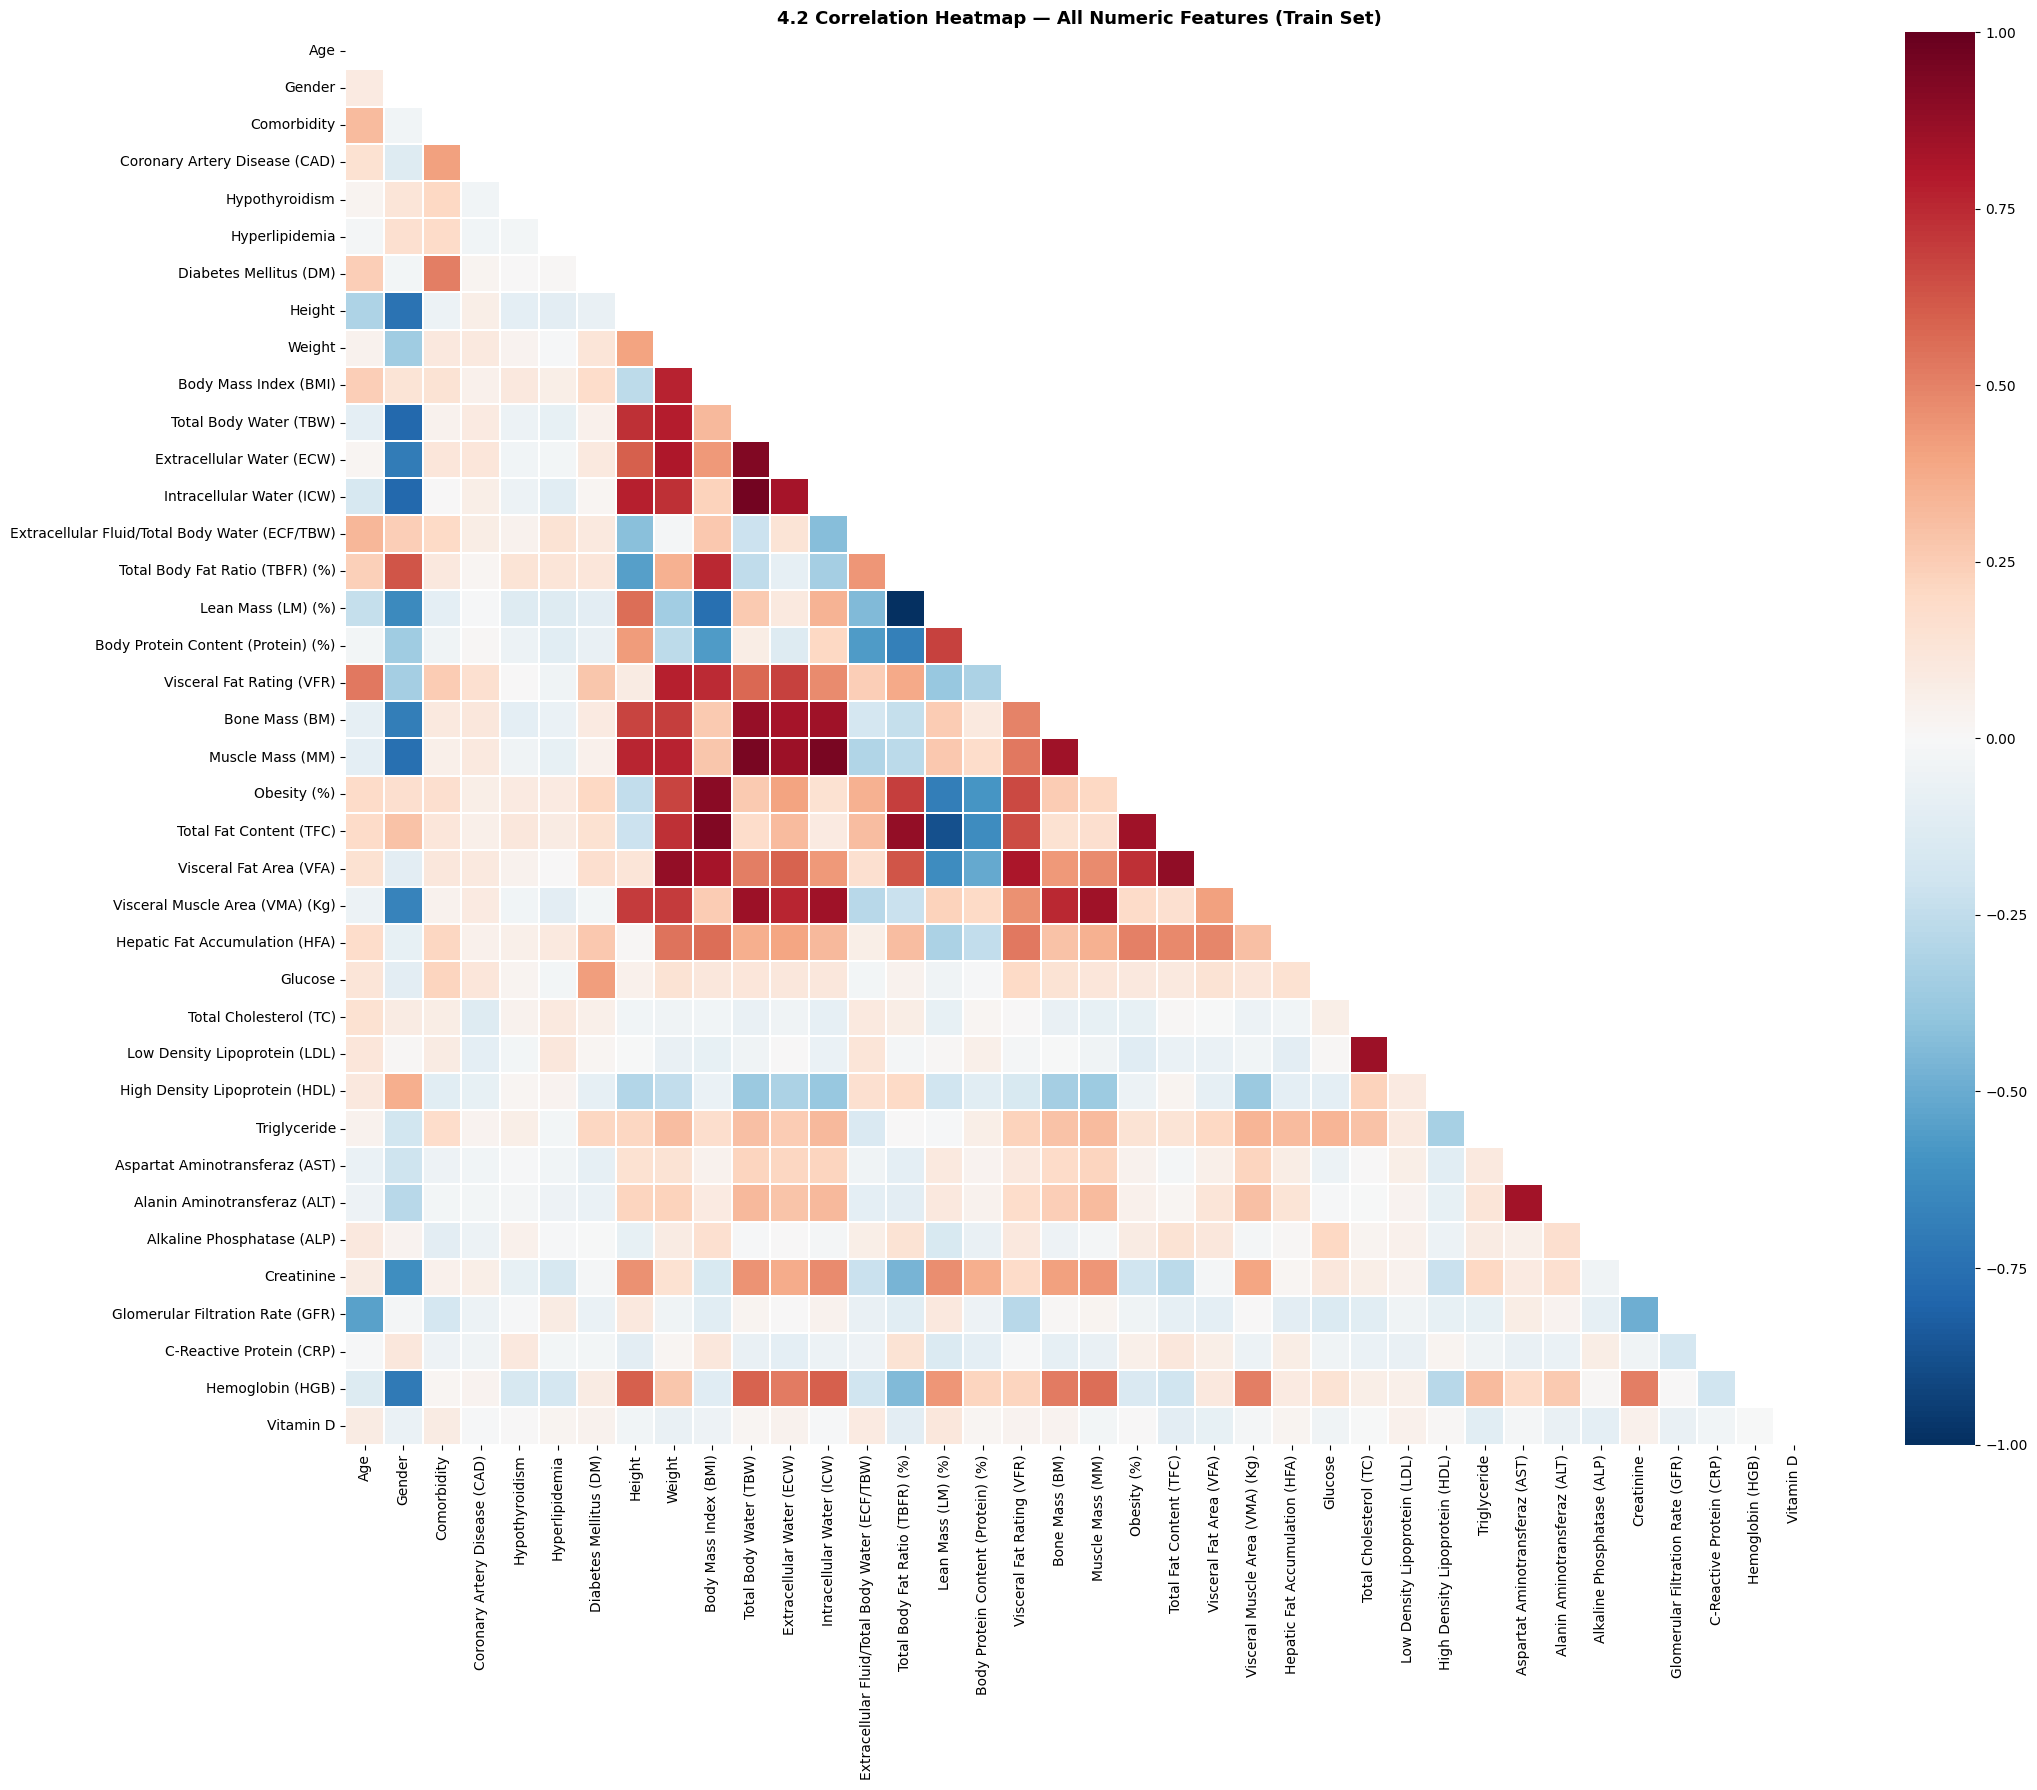

Figure saved: 4_2_correlation_heatmap.png

Feature pairs with |correlation| > 0.90:
  -0.992  |  Total Body Fat Ratio (TBFR) (%)  ↔  Lean Mass (LM) (%)
  +0.966  |  Total Body Water (TBW)  ↔  Intracellular Water (ICW)
  +0.951  |  Intracellular Water (ICW)  ↔  Muscle Mass (MM)
  +0.948  |  Total Body Water (TBW)  ↔  Muscle Mass (MM)
  +0.929  |  Total Body Water (TBW)  ↔  Extracellular Water (ECW)
  +0.922  |  Body Mass Index (BMI)  ↔  Total Fat Content (TFC)

Total high-correlation pairs found: 6


In [16]:
# --- 4.2 Multicollinearity heatmap ---

# Step 1: Cap Obesity (%) outlier on X_train only
obesity_col = COLS["obesity"]
Q1 = X_train[obesity_col].quantile(0.25)
Q3 = X_train[obesity_col].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

print(f"Obesity (%) — Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}, upper fence={upper_fence:.1f}")
print(f"Values above fence (train): {(X_train[obesity_col] > upper_fence).sum()}")

X_train_eda = X_train.copy()
X_train_eda[obesity_col] = X_train_eda[obesity_col].clip(upper=upper_fence)
print(f"Max after capping: {X_train_eda[obesity_col].max():.1f}")

# Step 2: Correlation matrix on numeric features
numeric_cols = X_train_eda.select_dtypes(include="number").columns.tolist()
corr_matrix = X_train_eda[numeric_cols].corr()

# Step 3: Plot heatmap
fig, ax = plt.subplots(figsize=(22, 18))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    annot=False,
    linewidths=0.3,
    ax=ax
)
ax.set_title("4.2 Correlation Heatmap — All Numeric Features (Train Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/figures_gallstone/4_2_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: 4_2_correlation_heatmap.png")

# Step 4: Print all pairs with |correlation| > 0.90
print("\nFeature pairs with |correlation| > 0.90:")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.90:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], round(val, 3)))

for a, b, v in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
    print(f"  {v:+.3f}  |  {a}  ↔  {b}")

print(f"\nTotal high-correlation pairs found: {len(high_corr_pairs)}")

#### Findings — 4.2

Obesity (%) capped at 86.4 (IQR upper fence) on X_train — 4 extreme values corrected
before computing correlations.

**High-correlation pairs identified (|r| > 0.90):**

| Pair | Correlation | Action in Phase 4 |
|---|---|---|
| TBFR (%) ↔ Lean Mass (LM) (%) | -0.992 | Drop Lean Mass — mathematical complement of TBFR |
| TBW ↔ ICW | +0.966 | Drop ICW — ICW is a component of TBW |
| ICW ↔ Muscle Mass | +0.951 | Drop Muscle Mass — redundant after ICW/TBW resolution |
| TBW ↔ Muscle Mass | +0.948 | Resolved by dropping Muscle Mass above |
| TBW ↔ ECW | +0.929 | Drop ECW — ECW is a component of TBW |
| BMI ↔ TFC | +0.922 | Drop TFC — BMI is a more standard clinical measure |

**Hypothesis: ✅ Confirmed.** Body composition features form two tight redundancy clusters:
- **Water cluster:** TBW, ECW, ICW, Muscle Mass — keep TBW only
- **Fat cluster:** TBFR, Lean Mass, TFC — keep TBFR only; BMI kept separately

**Phase 4 action:** Drop ECW, ICW, Muscle Mass, Lean Mass, and TFC before SelectKBest.
TBW and TBFR are kept as cluster representatives. BMI is kept independently.

### 4.3 What is the demographic profile of patients, and does it differ by disease status?

**Hypothesis:** Gallstone-positive patients (class 1) will skew older and female, consistent
with known gallstone epidemiology (age and female sex are established risk factors).

**Visualization:** Age KDE split by Gallstone Status + Gender stacked bar chart by class.

**Phase 4 action:** Confirms whether Age and Gender are meaningful features or potential
confounders that limit generalizability of the model.

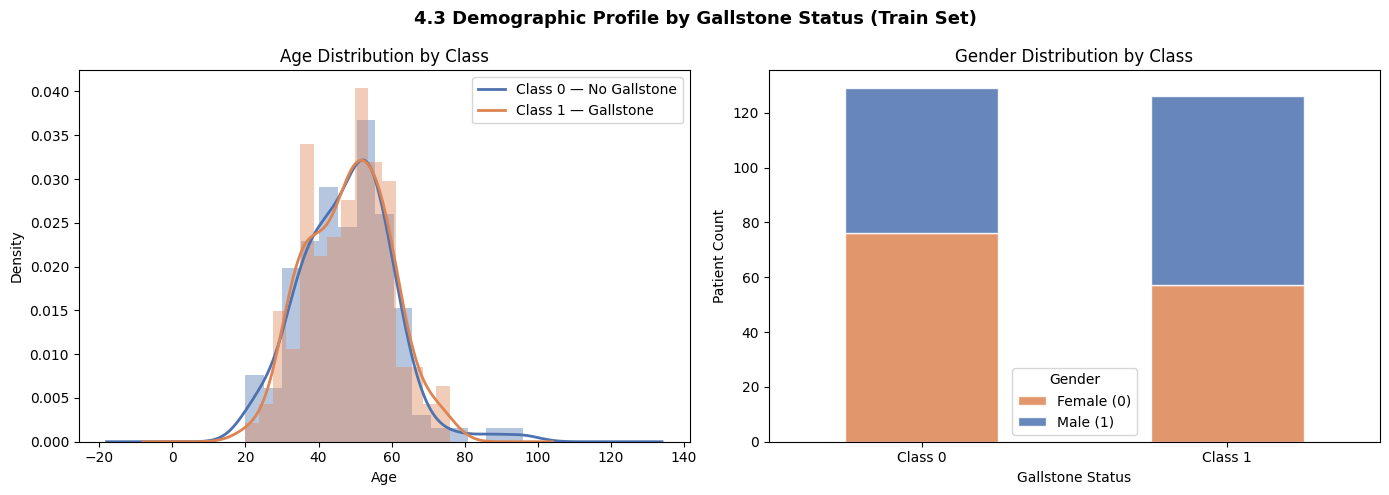

Figure saved: 4_3_demographic_profile.png

Age stats by class (train set):
                  count  mean   std   min   25%   50%   75%   max
Gallstone Status                                                 
0                 129.0  47.8  12.4  20.0  39.0  49.0  56.0  96.0
1                 126.0  48.3  11.3  20.0  39.0  49.0  56.0  76.0

Gender counts by class (0=Female, 1=Male):
         Female (0)  Male (1)
Class 0          76        53
Class 1          57        69


In [17]:
# --- 4.3 Demographic profile by Gallstone Status ---
train_eda[COLS["target"]] = y_train.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("4.3 Demographic Profile by Gallstone Status (Train Set)", fontsize=13, fontweight="bold")

# Plot 1: Age KDE by class
for cls, color, label in zip([0, 1], ["#4C72B0", "#DD8452"], ["Class 0 — No Gallstone", "Class 1 — Gallstone"]):
    data = train_eda.loc[train_eda[COLS["target"]] == cls, COLS["age"]]
    axes[0].hist(data, bins=15, alpha=0.4, color=color, density=True)
    data.plot.kde(ax=axes[0], color=color, linewidth=2, label=label)

axes[0].set_title("Age Distribution by Class")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Density")
axes[0].legend()

# Plot 2: Gender stacked bar by class
gender_counts = train_eda.groupby([COLS["target"], COLS["gender"]]).size().unstack(fill_value=0)
gender_counts.columns = ["Female (0)", "Male (1)"]
gender_counts.index = ["Class 0", "Class 1"]
gender_counts.plot(kind="bar", stacked=True, ax=axes[1],
                   color=["#DD8452", "#4C72B0"], alpha=0.85, edgecolor="white")
axes[1].set_title("Gender Distribution by Class")
axes[1].set_xlabel("Gallstone Status")
axes[1].set_ylabel("Patient Count")
axes[1].set_xticklabels(["Class 0", "Class 1"], rotation=0)
axes[1].legend(title="Gender")

plt.tight_layout()
plt.savefig("/content/figures_gallstone/4_3_demographic_profile.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: 4_3_demographic_profile.png")

# Print summary stats
print("\nAge stats by class (train set):")
print(train_eda.groupby(COLS["target"])[COLS["age"]].describe().round(1).to_string())
print("\nGender counts by class (0=Female, 1=Male):")
print(gender_counts.to_string())

#### Findings — 4.3

| Feature | Hypothesis | Observed | Verdict |
|---|---|---|---|
| Age | Older patients skew toward Class 1 | Mean 47.8 (C0) vs 48.3 (C1), median identical at 49 | ❌ Not confirmed |
| Gender | Female skews toward Class 1 | Class 0: 59% Female / Class 1: 55% Male | ❌ Not confirmed — reversed |

**Age:** Both classes are nearly identical in age distribution. The KDE curves overlap
almost perfectly — same peak (~50 years), same spread (std ~12 years), same median (49).
Age does not discriminate between classes in this dataset.

**Gender:** The distribution is reversed from the clinical hypothesis. Class 0 (no gallstone)
is female-dominated (59%), while Class 1 (gallstone) is male-dominated (55%). This contradicts
known gallstone epidemiology where female sex is an established risk factor. This likely
reflects a sampling bias in the study population rather than a genuine biological reversal.

**Generalizability note:** The near-identical age distributions and the reversed gender
finding suggest this dataset may not be representative of the general population. Results
should be interpreted with caution outside the study's original clinical context.

**Phase 4 action:** Age and Gender are kept in the feature set — they carry some signal
(particularly Gender, given the class imbalance) and SelectKBest will rank them objectively.
However, their limited discriminative power is noted as a generalizability limitation.